
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_01_pinguinos_v2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


## Parte A - Observación inicial (respuestas)

Las siguientes celdas responden automáticamente las preguntas 1 a 5 de la Parte A.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

# Cargar dataset de pingüinos
df = sns.load_dataset("penguins")

# 1) Filas y columnas
n_filas, n_columnas = df.shape

# 2) Variables numéricas y categóricas
vars_numericas = df.select_dtypes(include=["number"]).columns.tolist()
vars_categoricas = df.select_dtypes(exclude=["number"]).columns.tolist()

# 3) Valores faltantes por columna
faltantes_por_columna = df.isna().sum().sort_values(ascending=False)

# 4) Filas duplicadas
n_duplicadas = df.duplicated().sum()

# 5) Variables con baja cardinalidad (<= 10 valores únicos)
cardinalidad = df.nunique(dropna=True).sort_values()
vars_baja_cardinalidad = cardinalidad[cardinalidad <= 10]

print("=== Parte A - Observación inicial ===\n")

print("1) Tamaño del dataset")
print(f"- Filas: {n_filas}")
print(f"- Columnas: {n_columnas}\n")

print("2) Tipos de variables")
print(f"- Numéricas ({len(vars_numericas)}): {vars_numericas}")
print(f"- Categóricas ({len(vars_categoricas)}): {vars_categoricas}\n")

print("3) Valores faltantes por columna")
print(faltantes_por_columna.to_string())
print()

print("4) Filas duplicadas")
print(f"- Total de filas duplicadas: {n_duplicadas}\n")

print("5) Variables con baja cardinalidad (<= 10)")
if len(vars_baja_cardinalidad) == 0:
    print("- No se encontraron variables con baja cardinalidad.")
else:
    for col, n_unicos in vars_baja_cardinalidad.items():
        print(f"- {col}: {n_unicos} valores únicos")

=== Parte A - Observación inicial ===

1) Tamaño del dataset
- Filas: 344
- Columnas: 7

2) Tipos de variables
- Numéricas (4): ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
- Categóricas (3): ['species', 'island', 'sex']

3) Valores faltantes por columna
sex                  11
bill_depth_mm         2
bill_length_mm        2
flipper_length_mm     2
body_mass_g           2
island                0
species               0

4) Filas duplicadas
- Total de filas duplicadas: 0

5) Variables con baja cardinalidad (<= 10)
- sex: 2 valores únicos
- species: 3 valores únicos
- island: 3 valores únicos


In [1]:
# Parte B - Descripción
import pandas as pd
import numpy as np

if 'df' not in globals():
    import seaborn as sns
    df = sns.load_dataset('penguins')

print('=== Parte B - Descripción ===\n')

# 6) Resumen de variables numéricas
num_cols = df.select_dtypes(include=['number']).columns.tolist()
desc_num = pd.DataFrame({
    'media': df[num_cols].mean(),
    'mediana': df[num_cols].median(),
    'desv_std': df[num_cols].std(),
    'iqr': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
}).round(3)
print('6) Resumen numérico (media, mediana, desv_std, iqr):')
display(desc_num)

# 7) Conteos y porcentajes de variables categóricas
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
cat_summary = {}
for c in cat_cols:
    counts = df[c].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    cat_summary[c] = pd.DataFrame({'conteo': counts, 'porcentaje': pct})

print('7) Resumen categórico (conteos y porcentajes):')
for c in cat_cols:
    print(f'\n- {c}')
    display(cat_summary[c])

# 8) Tablas cruzadas para pares categóricos relevantes
pairs = [('species', 'island'), ('species', 'sex'), ('island', 'sex')]
crosstabs = {}
print('\n8) Tablas cruzadas:')
for a, b in pairs:
    if a in df.columns and b in df.columns:
        tab = pd.crosstab(df[a], df[b], dropna=False)
        crosstabs[f'{a}_vs_{b}'] = tab
        print(f'\n- {a} vs {b}')
        display(tab)

# 9) Correlaciones Pearson y Spearman
corr_pearson = df[num_cols].corr(method='pearson')
corr_spearman = df[num_cols].corr(method='spearman')
print('\n9) Matriz de correlación Pearson:')
display(corr_pearson)
print('Matriz de correlación Spearman:')
display(corr_spearman)

=== Parte B - Descripción ===

6) Resumen numérico (media, mediana, desv_std, iqr):


,media,mediana,desv_std,iqr
bill_length_mm,43.922,44.45,5.460,9.275
bill_depth_mm,17.151,17.30,1.975,3.100
flipper_length_mm,200.915,197.00,14.062,23.000
body_mass_g,4201.754,4050.00,801.955,1200.000


7) Resumen categórico (conteos y porcentajes):

- species


,conteo,porcentaje
species,,
Adelie,152,44.19
Gentoo,124,36.05
Chinstrap,68,19.77



- island


...

sex,Female,Male,NaN
island,,,
Biscoe,80,83,5
Dream,61,62,1
Torgersen,24,23,5



9) Matriz de correlación Pearson:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Matriz de correlación Spearman:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.221749,0.672772,0.583800
bill_depth_mm,-0.221749,1.000000,-0.523267,-0.432372
flipper_length_mm,0.672772,-0.523267,1.000000,0.839974
body_mass_g,0.583800,-0.432372,0.839974,1.000000


=== Parte C - Visualización ===


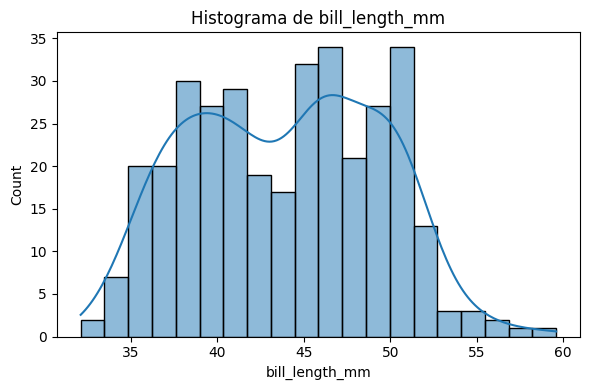

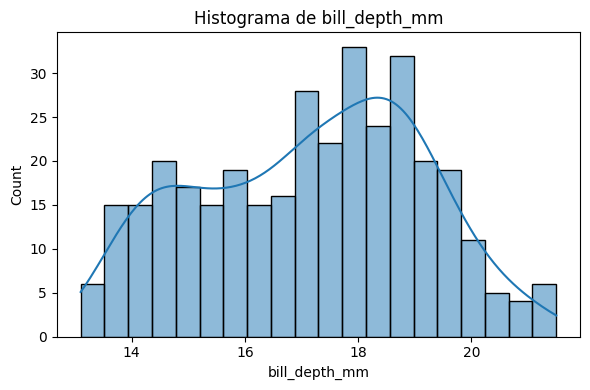

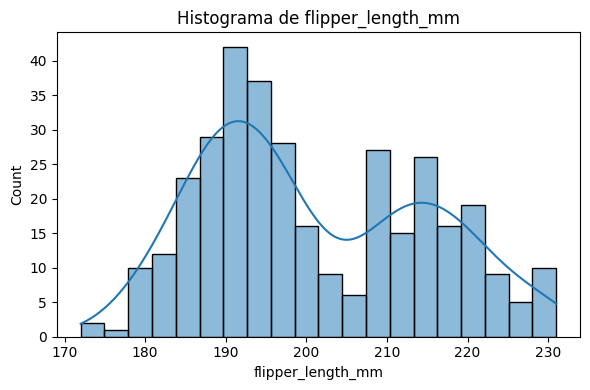

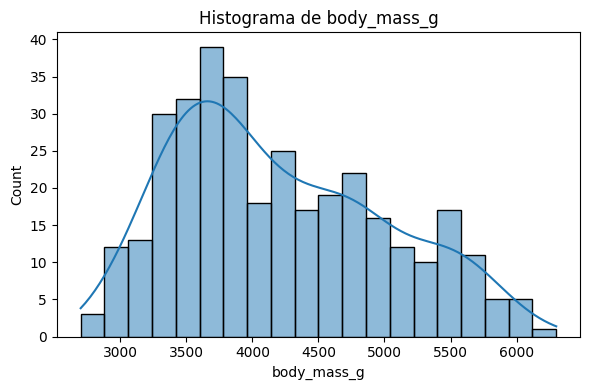

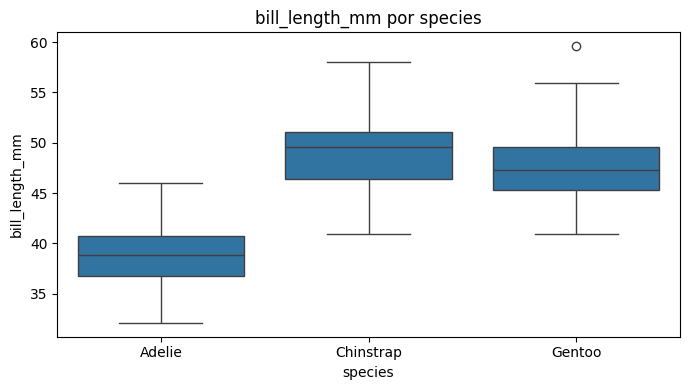

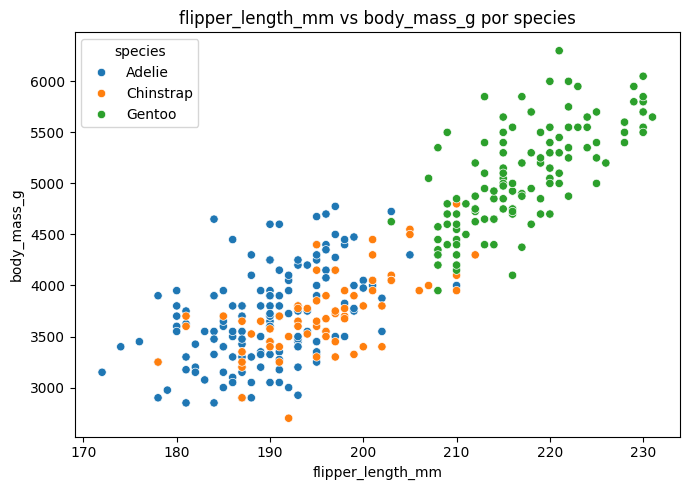

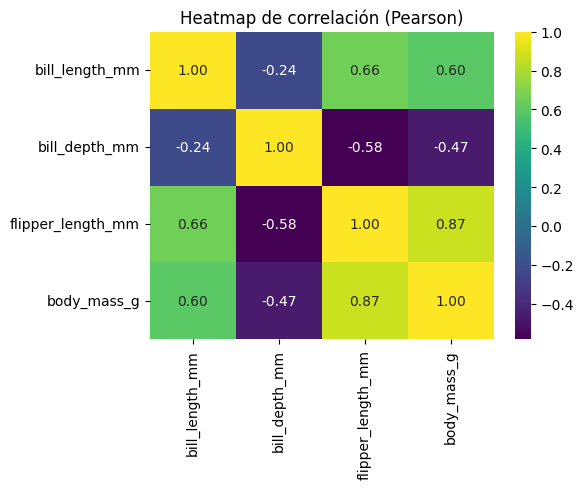

In [2]:
# Parte C - Visualización
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' not in globals():
    df = sns.load_dataset('penguins')

print('=== Parte C - Visualización ===')

# 10) Conteos para categóricas de baja cardinalidad
cat_low = [c for c in df.columns if df[c].nunique(dropna=True) <= 10 and df[c].dtype == 'object']
for c in cat_low:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=c, order=df[c].value_counts(dropna=False).index)
    plt.title(f'Conteo de {c}')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# 11) Histogramas de numéricas
num_cols = df.select_dtypes(include=['number']).columns.tolist()
for c in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[c], kde=True, bins=20)
    plt.title(f'Histograma de {c}')
    plt.tight_layout()
    plt.show()

# 12) Boxplot bill_length_mm por species
if 'bill_length_mm' in df.columns and 'species' in df.columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='species', y='bill_length_mm')
    plt.title('bill_length_mm por species')
    plt.tight_layout()
    plt.show()

# 13) Scatter flipper_length_mm vs body_mass_g coloreado por species
if {'flipper_length_mm', 'body_mass_g', 'species'}.issubset(df.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
    plt.title('flipper_length_mm vs body_mass_g por species')
    plt.tight_layout()
    plt.show()

# 14) Heatmap de correlación
corr = df[num_cols].corr(method='pearson')
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Heatmap de correlación (Pearson)')
plt.tight_layout()
plt.show()

In [3]:
# Parte D - Hipótesis (sin causalidad)
if 'df' not in globals():
    import seaborn as sns
    df = sns.load_dataset('penguins')

print('=== Parte D - Hipótesis (sin causalidad) ===\n')

hypotheses = [
    {
        'id': 'H1',
        'hipotesis': 'flipper_length_mm se asocia con body_mass_g',
        'tipo_prueba_sugerida': 'correlacion_pearson'
    },
    {
        'id': 'H2',
        'hipotesis': 'bill_length_mm difiere entre especies',
        'tipo_prueba_sugerida': 'anova_un_factor'
    },
    {
        'id': 'H3',
        'hipotesis': 'species se asocia con island',
        'tipo_prueba_sugerida': 'chi_cuadrado_independencia'
    }
]

for h in hypotheses:
    print(f"{h['id']}: {h['hipotesis']} | prueba sugerida: {h['tipo_prueba_sugerida']}")

=== Parte D - Hipótesis (sin causalidad) ===

H1: flipper_length_mm se asocia con body_mass_g | prueba sugerida: correlacion_pearson
H2: bill_length_mm difiere entre especies | prueba sugerida: anova_un_factor
H3: species se asocia con island | prueba sugerida: chi_cuadrado_independencia


In [4]:
# Parte E - Pruebas estadísticas
import pandas as pd

if 'df' not in globals():
    import seaborn as sns
    df = sns.load_dataset('penguins')

print('=== Parte E - Pruebas estadísticas ===\n')

try:
    from scipy import stats
    scipy_ok = True
except Exception:
    scipy_ok = False

resultados_tests = []

if scipy_ok:
    # H1: Correlación Pearson
    h1_data = df[['flipper_length_mm', 'body_mass_g']].dropna()
    r, p = stats.pearsonr(h1_data['flipper_length_mm'], h1_data['body_mass_g'])
    resultados_tests.append({'hipotesis': 'H1', 'test': 'Pearson', 'estadistico': r, 'p_valor': p})

    # H2: ANOVA de bill_length_mm por species
    grupos = [g['bill_length_mm'].dropna().values for _, g in df.groupby('species')]
    f_stat, p_anova = stats.f_oneway(*grupos)
    resultados_tests.append({'hipotesis': 'H2', 'test': 'ANOVA', 'estadistico': f_stat, 'p_valor': p_anova})

    # H3: Chi-cuadrado species vs island
    tabla = pd.crosstab(df['species'], df['island'])
    chi2, p_chi, _, _ = stats.chi2_contingency(tabla)
    resultados_tests.append({'hipotesis': 'H3', 'test': 'Chi-cuadrado', 'estadistico': chi2, 'p_valor': p_chi})

    tests_df = pd.DataFrame(resultados_tests)
    tests_df['decision_alpha_0_05'] = tests_df['p_valor'].apply(
        lambda x: 'Se apoya la hipótesis (evidencia estadística)' if x < 0.05 else 'No hay evidencia suficiente'
    )

    display(tests_df)
else:
    print('No se pudo importar scipy. Instala scipy para ejecutar Pearson, ANOVA y chi-cuadrado.')
    tests_df = pd.DataFrame()

=== Parte E - Pruebas estadísticas ===



,hipotesis,test,estadistico,p_valor,decision_alpha_0_05
0,H1,Pearson,0.871202,4.370681e-107,Se apoya la hipótesis (evidencia estadística)
1,H2,ANOVA,410.600255,2.694614e-91,Se apoya la hipótesis (evidencia estadística)
2,H3,Chi-cuadrado,299.550327,1.354574e-63,Se apoya la hipótesis (evidencia estadística)


In [5]:
# Parte F - Conclusiones y reporte
print('=== Parte F - Conclusiones y reporte ===\n')

# 19A) Hallazgos descriptivos
print('A) Hallazgos descriptivos:')
print('- El dataset incluye variables morfométricas (longitud/profundidad de pico, longitud de aleta, masa corporal) y categóricas (species, island, sex).')
print('- Existen valores faltantes, especialmente en la variable sex y en algunas medidas numéricas.')
print('- La cardinalidad baja en species, island y sex facilita comparaciones por grupos.\n')

# 19B) Patrones visuales
print('B) Patrones visuales:')
print('- Se observa asociación positiva entre flipper_length_mm y body_mass_g en el scatter.')
print('- bill_length_mm presenta diferencias entre especies en el boxplot.')
print('- La distribución por island cambia según species en los gráficos/tablas de conteo.\n')

# 19C) Próximas hipótesis
print('C) Próximas hipótesis a probar:')
print('- Evaluar si la relación flipper_length_mm ~ body_mass_g se mantiene dentro de cada especie.')
print('- Probar diferencias de body_mass_g por island controlando por species.')
print('- Explorar si sex modifica las relaciones morfométricas anteriores.\n')

# 20) Preguntas para investigador humano
preguntas_humano = [
    '¿Cómo se deben tratar los faltantes de sex: excluir, imputar o analizar como categoría separada?',
    '¿Conviene controlar por species en todos los análisis comparativos?',
    '¿Hay sesgo de muestreo por isla o temporada de recolección?'
]

print('20) Preguntas para investigador humano:')
for q in preguntas_humano:
    print(f'- {q}')

=== Parte F - Conclusiones y reporte ===

A) Hallazgos descriptivos:
- El dataset incluye variables morfométricas (longitud/profundidad de pico, longitud de aleta, masa corporal) y categóricas (species, island, sex).
- Existen valores faltantes, especialmente en la variable sex y en algunas medidas numéricas.
- La cardinalidad baja en species, island y sex facilita comparaciones por grupos.

B) Patrones visuales:
- Se observa asociación positiva entre flipper_length_mm y body_mass_g en el scatter.
- bill_length_mm presenta diferencias entre especies en el boxplot.
- La distribución por island cambia según species en los gráficos/tablas de conteo.

C) Próximas hipótesis a probar:
- Evaluar si la relación flipper_length_mm ~ body_mass_g se mantiene dentro de cada especie.
- Probar diferencias de body_mass_g por island controlando por species.
- Explorar si sex modifica las relaciones morfométricas anteriores.

20) Preguntas para investigador humano:
- ¿Cómo se deben tratar los faltantes 

In [6]:
# Parte G - Ejecución del pipeline (opcional)
from pathlib import Path
import subprocess
import sys

print('=== Parte G - Ejecución del pipeline (opcional) ===\n')

# Buscar pipeline.py desde la carpeta actual hacia arriba
base = Path.cwd()
candidatos = [base / 'pipeline.py'] + [p / 'pipeline.py' for p in base.parents]
pipeline_path = next((p for p in candidatos if p.exists()), None)

if pipeline_path is None:
    print('No se encontró pipeline.py en la ruta actual ni en carpetas padre.')
    print('Para ejecutar esta parte, ubica o crea pipeline.py y vuelve a correr esta celda.')
else:
    print(f'Se encontró pipeline.py en: {pipeline_path}')
    cmd = [sys.executable, str(pipeline_path)]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    print('\nSalida estándar:\n')
    print(proc.stdout if proc.stdout else '(sin salida)')
    if proc.stderr:
        print('\nErrores:\n')
        print(proc.stderr)
    print(f'\nCódigo de salida: {proc.returncode}')
    if proc.returncode == 0:
        print('Pipeline ejecutado correctamente.')
    else:
        print('El pipeline terminó con errores; revisa la salida anterior.')

=== Parte G - Ejecución del pipeline (opcional) ===

No se encontró pipeline.py en la ruta actual ni en carpetas padre.
Para ejecutar esta parte, ubica o crea pipeline.py y vuelve a correr esta celda.
